After building a dictionary of roots and their associated words, we compute the pairwise semantic similarity between all words within each root family using a word embedding model. For each root, we calculate the average similarity across all word pairs, which serves as the semantic coherence score for that root family.

In [18]:


import numpy as np
import pickle
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
def calculate_semantic_coherence(root_to_words, model, threshold=None):
    """
    Calculate semantic coherence for each root using average pairwise semantic similarity.
    """
    semantic_coherence = {} 


    for root, words in root_to_words.items():

        # Uncomment the following two lines to filter out roots with fewer words than the threshold
        # if len(words) < threshold:
        #     continue  # Skip roots with fewer words than the threshold

        similarities = []

        for i in range(len(words)):
            for j in range(i + 1, len(words)):
                try:
                    similarity = model.wv.similarity(words[i], words[j])
                    similarities.append(similarity)
                except KeyError:
                    continue

        if similarities:
            average_similarity = np.mean(similarities)
            semantic_coherence[root] = average_similarity

    return semantic_coherence

def main():
    # Load the dictionary and the word2vec model
    dictionary_path = "/home/safeer.alyubary/Semantic-Coherence/src/output/root_to_words_dict_v2.pkl"
    model_path = "/home/safeer.alyubary/Semantic-Coherence/data_files/models/word2vec/word2vec.model"
    output_path = "/home/safeer.alyubary/Semantic-Coherence/src/output/semantic_coherence_results_word_level_no_frequency_weighting.txt"


    print("Loading dictionary and word2vec model...")
    with open(dictionary_path, "rb") as file:
        root_to_words = pickle.load(file)

    model = Word2Vec.load(model_path)

    # Calculate semantic coherence
    print("Calculating semantic coherence...")
    semantic_coherence = calculate_semantic_coherence(root_to_words, model)

    # Save the results to a file
    print("Saving semantic coherence results to file...")
    with open(output_path, "w", encoding="utf-8") as file:
        for root, coherence in semantic_coherence.items():
            file.write(f"Root: {root}, Semantic Coherence: {coherence}\n")

    print(f"Semantic coherence results saved to {output_path}")

if __name__ == "__main__":
    main()


Loading dictionary and word2vec model...
Calculating semantic coherence...
Saving semantic coherence results to file...
Semantic coherence results saved to /home/safeer.alyubary/Semantic-Coherence/src/output/semantic_coherence_results_word_level_no_frequency_weighting.txt


##  Visualizing Semantic Coherence Results

In [23]:
def load_semantic_coherence(file_path):
    roots = []
    coherences = []
    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            root, coherence = line.strip().split(", ")
            roots.append(root.split(": ")[1])
            coherences.append(float(coherence.split(": ")[1]))
    return roots, coherences
roots, coherences = load_semantic_coherence("/home/safeer.alyubary/Semantic-Coherence/src/output/semantic_coherence_results_word_level_no_frequency_weighting.txt")

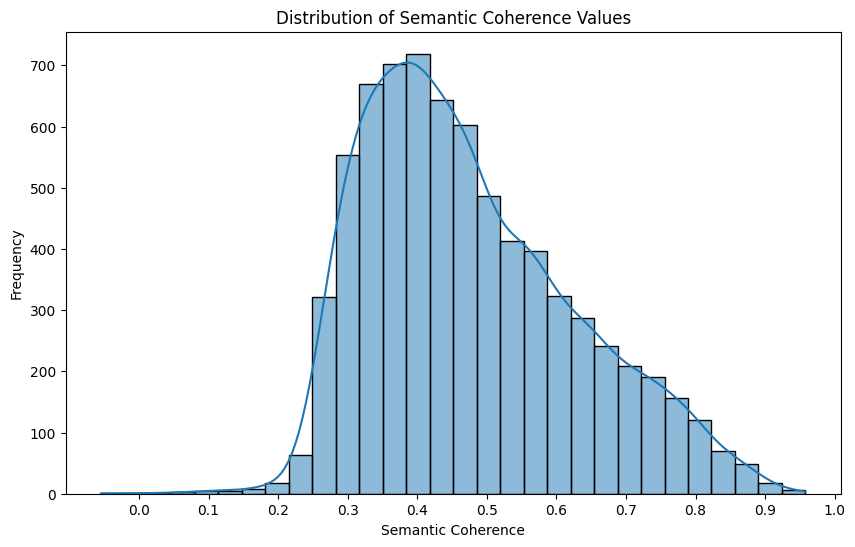

In [24]:

def plot_histogram(coherences):
    plt.figure(figsize=(10, 6))
    sns.histplot(coherences, kde=True, bins=30)
    plt.title('Distribution of Semantic Coherence Values')
    plt.xlabel('Semantic Coherence')
    plt.ylabel('Frequency')
    plt.xticks([i/10 for i in range(11)])
    plt.show()
plot_histogram(coherences)

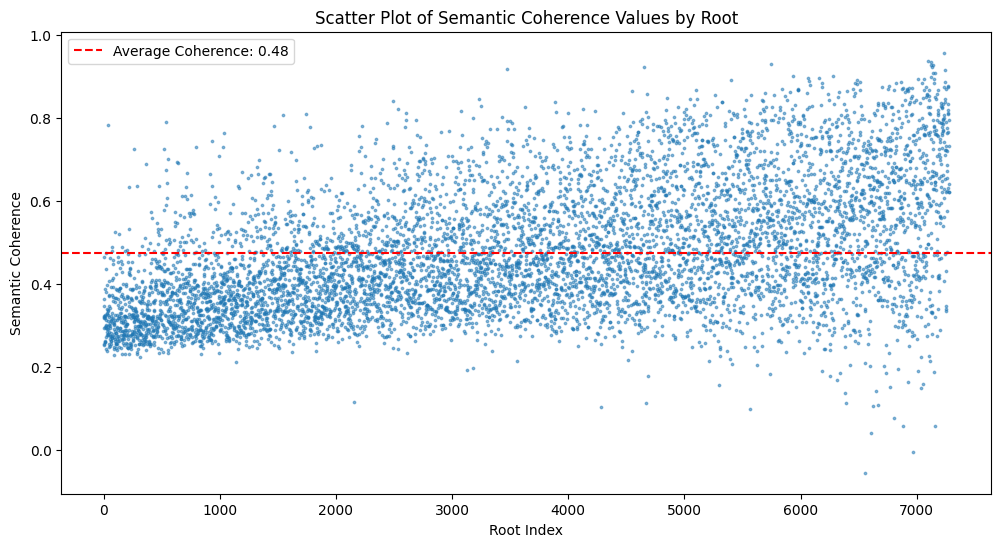

In [25]:
def plot_scatter_with_average(roots, coherences):
    plt.figure(figsize=(12, 6))
    
    # Reduce point size and add transparency
    plt.scatter(range(len(coherences)), coherences, alpha=0.5, s=3)
    
    # Calculate and plot the average coherence
    avg_coherence = np.mean(coherences)
    plt.axhline(y=avg_coherence, color='red', linestyle='--', label=f'Average Coherence: {avg_coherence:.2f}')
    
    plt.title('Scatter Plot of Semantic Coherence Values by Root')
    plt.xlabel('Root Index')
    plt.ylabel('Semantic Coherence')
    plt.legend()
    plt.show()

plot_scatter_with_average(roots, coherences)


## Frequency weighted semantic coherence

In this version, pairwise semantic similarity is weighted by word frequency.

The idea is that word pairs involving more frequent words should contribute more to the final coherence score.

Instead of calculating a simple unweighted average:

average_similarity = np.mean(similarities)

we calculate a weighted average:

weighted_average_similarity = sum(similarity * weight) / sum(weights)

where the weight for each word pair is calculated as the product of the two word frequencies.

In [27]:
def load_word_frequencies(freq_path):

    word_frequencies = {}

    with open(freq_path, "r", encoding="utf-8") as file:
        for line in file:
            parts = line.strip().split()

            if len(parts) < 2:
                continue

            word = parts[0]
            frequency = float(parts[1])

            word_frequencies[word] = frequency

    return word_frequencies

In [28]:
def calculate_frequency_weighted_semantic_coherence(root_to_words, model, word_frequencies, threshold=None):
    """
    Calculate semantic coherence for each root using frequency-weighted
    average pairwise semantic similarity.
    """
    semantic_coherence = {}

    for root, words in root_to_words.items():

        # Uncomment the following two lines to filter out roots with fewer words than the threshold
        # if threshold is not None and len(words) < threshold:
        #     continue

        weighted_similarities_sum = 0
        weights_sum = 0

        for i in range(len(words)):
            for j in range(i + 1, len(words)):
                word1 = words[i]
                word2 = words[j]

                try:
                    similarity = model.wv.similarity(word1, word2)

                    freq1 = word_frequencies.get(word1, 0)
                    freq2 = word_frequencies.get(word2, 0)

                    pair_weight = freq1 * freq2

                    if pair_weight == 0:
                        continue

                    weighted_similarities_sum += similarity * pair_weight
                    weights_sum += pair_weight

                except KeyError:
                    continue

        if weights_sum > 0:
            weighted_average_similarity = weighted_similarities_sum / weights_sum
            semantic_coherence[root] = weighted_average_similarity

    return semantic_coherence


def main():
    # Load the dictionary and the word2vec model
    dictionary_path = "/home/safeer.alyubary/Semantic-Coherence/src/output/root_to_words_dict_v2.pkl"
    model_path = "/home/safeer.alyubary/Semantic-Coherence/data_files/models/word2vec/word2vec.model"
    frequency_path = "/home/safeer.alyubary/Semantic-Coherence/data_files/data_stats/word_frequencies_main.txt"
    output_path = "/home/safeer.alyubary/Semantic-Coherence/src/output/semantic_coherence_results_word_level_frequency_weighting.txt"

    print("Loading dictionary and word2vec model...")
    with open(dictionary_path, "rb") as file:
        root_to_words = pickle.load(file)

    model = Word2Vec.load(model_path)
    word_frequencies = load_word_frequencies(frequency_path)

    # Calculate semantic coherence
    print("Calculating semantic coherence...")
    semantic_coherence = calculate_frequency_weighted_semantic_coherence(root_to_words, model, word_frequencies, threshold=None)

    # Save the results to a file
    print("Saving semantic coherence results to file...")
    with open(output_path, "w", encoding="utf-8") as file:
        for root, coherence in semantic_coherence.items():
            file.write(f"Root: {root}, Semantic Coherence: {coherence}\n")

    print(f"Semantic coherence results saved to {output_path}")

if __name__ == "__main__":
    main()

Loading dictionary and word2vec model...
Calculating semantic coherence...
Saving semantic coherence results to file...
Semantic coherence results saved to /home/safeer.alyubary/Semantic-Coherence/src/output/semantic_coherence_results_word_level_frequency_weighting.txt


##  Visualizing Semantic Coherence Results

In [29]:
def load_semantic_coherence(file_path):
    roots = []
    coherences = []
    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            root, coherence = line.strip().split(", ")
            roots.append(root.split(": ")[1])
            coherences.append(float(coherence.split(": ")[1]))
    return roots, coherences
roots, coherences = load_semantic_coherence("/home/safeer.alyubary/Semantic-Coherence/src/output/semantic_coherence_results_word_level_frequency_weighting.txt")

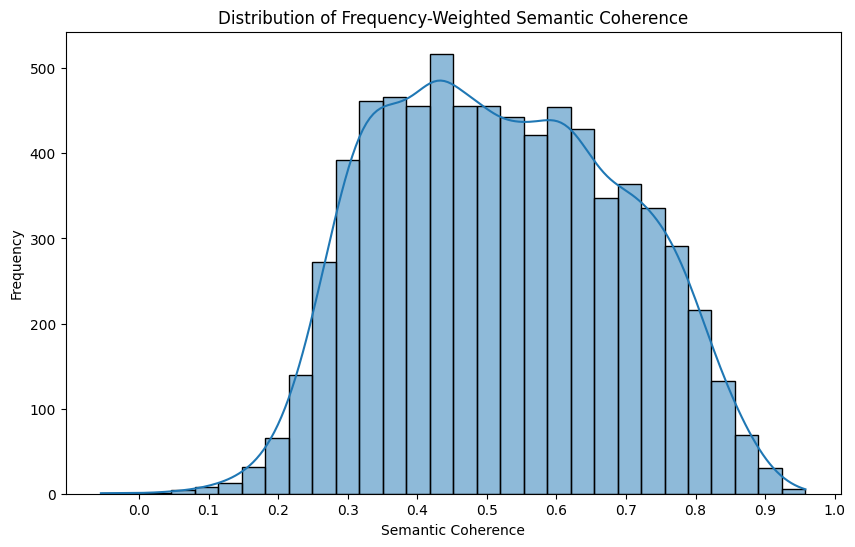

In [32]:

def plot_histogram(coherences):
    plt.figure(figsize=(10, 6))
    sns.histplot(coherences, kde=True, bins=30)
    plt.title('Distribution of Frequency-Weighted Semantic Coherence')
    plt.xlabel('Semantic Coherence')
    plt.ylabel('Frequency')
    plt.xticks([i/10 for i in range(11)])
    plt.show()
plot_histogram(coherences)

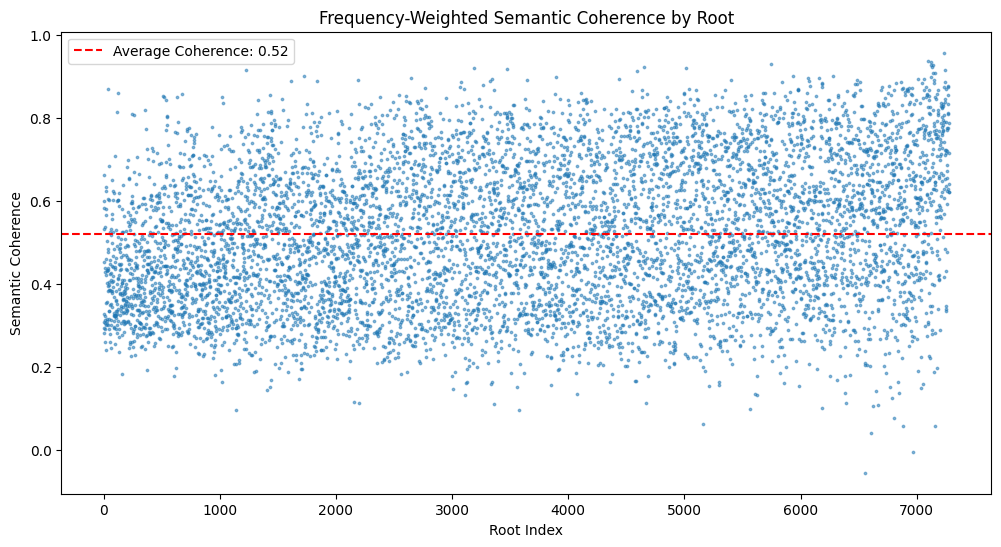

In [31]:

def plot_scatter_with_average(roots, coherences):
    plt.figure(figsize=(12, 6))
    
    # Reduce point size and add transparency
    plt.scatter(range(len(coherences)), coherences, alpha=0.5, s=3)
    
    # Calculate and plot the average coherence
    avg_coherence = np.mean(coherences)
    plt.axhline(y=avg_coherence, color='red', linestyle='--', label=f'Average Coherence: {avg_coherence:.2f}')
    
    plt.title('Frequency-Weighted Semantic Coherence by Root')
    plt.xlabel('Root Index')
    plt.ylabel('Semantic Coherence')
    plt.legend()
    plt.show()

plot_scatter_with_average(roots, coherences)
